# Employee Performance PCA: IBM HR Analytics Dataset

**Authors:** Owen Lindsey, Clay Kelly, John Hickox
**Instructor:** Professor Ahsan  
**Course:** AIT-104: Data Mining and Machine Learning  
**Institution:** Grand Canyon University  

**Video Link:** [Youtube Video](https://youtu.be/LDFTEAwbmzw)
**Dataset:** [IBM HR Analytics Employee Attrition & Performance Dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)  
**Source Code:** [ipynb src code](https://github.com/omniV1/GCU_SWE_2023-2025/blob/main/AIT-104-Data-mining-machine-learning/Code%20Projects/Employee_Performance_PCA.ipynb)

# Principal Component Analysis for Employee Performance: Bonus Allocation & Professional Development

## Introduction

This technical report presents a comprehensive Principal Component Analysis (PCA) of employee performance indicators using the IBM HR Analytics Employee Attrition & Performance dataset. The analysis follows a structured workflow across three main parts, providing both quantitative dimensionality reduction results and interpretable latent components suitable for HR policy applications including bonus allocation and professional development planning.

**Document Structure:** This notebook is organized into three main parts:
- **Part I:** Data Preparation and Preliminary Steps (Steps 1-6)
- **Part II:** Verifying PCA Assumptions (Three assumption checks)
- **Part III:** Implement PCA (Steps 1-10)

Each part follows a systematic workflow, ensuring consistent methodology and comprehensive documentation.

## Report Structure and Workflow

**Dataset Selection:** The assignment requires applying PCA to datasets with at least 10 attributes. This analysis uses the IBM HR Analytics dataset, which contains 35 HR indicators across 1,470 employee records. While the assignment references datasets with 50,000+ rows, this is the official resource supplied in the course materials and is therefore analyzed as-is. The dataset provides a comprehensive view of employee characteristics, performance metrics, and organizational factors that influence bonus allocation decisions.

The assignment requires implementation of PCA following a structured process. Each step addresses a critical aspect of the analysis, from initial data preparation through final interpretation and model validation. The workflow steps are:

**Part I: Data Preparation and Preliminary Steps**
- **Step 1:** Explain interpretation of performance and predictors
- **Step 2:** Load PCA-related packages
- **Step 3:** Data setup and exploration
- **Step 4:** Compute correlation matrix
- **Step 5:** Compute variance-covariance matrix
- **Step 6:** Check statistical significance of bivariate correlations

**Part II: Verify PCA Assumptions**
- **Assumption 1:** Sphericity (Bartlett Test of Sphericity)
- **Assumption 2:** Sample adequacy (Kaiser-Meyer-Olkin Measure)
- **Assumption 3:** Positive determinant of correlation matrix

**Part III: Implement PCA**
- **Step 1:** Calculate number of components
- **Step 2:** Analyze eigenvalues
- **Step 3:** Decide which variables to keep and variance percentage
- **Step 4:** Assess residual error and Cronbach's alpha reliability
- **Step 5:** Create scree plot
- **Step 6:** Plot component structure
- **Step 7:** Compute principal component scores using first set of weights
- **Step 8:** Convert output to 0–100 scale
- **Step 9:** Plot histogram
- **Step 10:** Summarize results and explain meaning in predictive model context

All steps have been completed with detailed explanations provided throughout this document.

---

## About the Dataset

### **IBM HR Analytics Employee Attrition & Performance Dataset**

> The IBM HR Analytics dataset captures comprehensive employee information including demographic characteristics, job-related factors, compensation details, and performance metrics. This dataset is widely used for HR analytics, employee retention analysis, and performance prediction tasks.

#### Dataset Characteristics

| Property | Value | Status |
|----------|-------|--------|
| **Total Features** | 35 HR indicators | Exceeds requirement (≥10) |
| **Active Features** | 31 indicators (after preprocessing) | Exceeds requirement (≥10) |
| **Total Instances** | 1,470 employee records | Meets requirement |
| **Data Type** | Mixed (numerical, categorical) | HR analytics data |
| **Task** | Dimensionality reduction via PCA | Extract latent performance factors |
| **Target Application** | Bonus allocation & professional development | HR policy decisions |

**Key Insight:** This is a real-world HR analytics problem where PCA will identify underlying dimensions of employee performance that can guide bonus allocation and development planning decisions.

#### Feature Categories and Interpretation

The dataset contains 35 features organized into several categories that capture different aspects of employee characteristics and organizational context:

**Demographic Features** include age, gender, marital status, and education level, providing baseline employee characteristics. **Job-Related Features** capture organizational context including department, job role, job level, and job involvement, describing the employee's position and engagement within the organization. **Compensation Features** include monthly income, percent salary hike, stock option level, and daily rate, representing financial rewards and compensation structure. **Tenure Features** measure time-based factors such as total working years, years at company, years in current role, years since last promotion, and years with current manager, indicating career progression and organizational commitment. **Performance Features** include performance rating and job satisfaction metrics, directly measuring employee output and engagement. **Work-Life Features** capture work-life balance indicators including overtime, business travel frequency, distance from home, and relationship satisfaction, describing the employee's work environment and personal circumstances.

**Preprocessing Notes:** Four features (`EmployeeNumber`, `EmployeeCount`, `Over18`, `StandardHours`) are removed during preprocessing because they provide no variance for PCA—`EmployeeNumber` is a unique identifier, while `EmployeeCount`, `Over18`, and `StandardHours` are constants across all records. Categorical features are encoded using label encoding to convert them to numerical format suitable for PCA analysis.

---

In [59]:
# (Optional) Environment setup: uncomment if you need to install dependencies inside this kernel
# %pip install pandas numpy scipy scikit-learn seaborn matplotlib

---

---

# Part I: Data Preparation and Preliminary Steps

## Overview

This section implements the data preparation and preliminary analysis steps required before performing PCA. Each step includes both implementation and explanation of its meaning in the HR analytics context.

**Transition from Introduction:** Having established the dataset characteristics and methodology overview, we now proceed to prepare the data for PCA analysis. This involves loading packages, exploring the data structure, computing correlation matrices, and verifying statistical relationships between variables.

**What to Expect:** This section will walk through all six preliminary steps:
1. Explaining interpretation of performance and predictors
2. Loading required packages
3. Data setup and exploration
4. Computing correlation matrix
5. Computing variance-covariance matrix
6. Checking statistical significance of bivariate correlations

---

## Step 1: Explain Interpretation of Performance and Predictors

**Transition from Overview:** Before beginning the technical analysis, we must establish a clear understanding of what we mean by "performance" and which variables serve as predictors in this HR analytics context.

### Performance Definition

Performance in this analysis is observed through two complementary perspectives:

1. **Observed Performance**: The provided `PerformanceRating` field serves as a direct measure of employee performance as evaluated by the organization. This is an explicit performance metric that can be used for validation and comparison.

2. **Latent Performance Constructs**: PCA will create latent (hidden) constructs that capture underlying dimensions of employee performance that may not be directly observable. These latent components will summarize patterns across multiple correlated indicators, revealing the fundamental dimensions that drive performance variation.

### Predictors of Performance

Predictors of performance in this exercise include several categories of HR indicators:

**Compensation Signals:**
- `MonthlyIncome`: Base compensation level, often correlated with experience and performance
- `PercentSalaryHike`: Recent salary increases, indicating performance recognition

**Engagement Measures:**
- `JobInvolvement`: Employee's level of engagement with their role
- `RelationshipSatisfaction`: Satisfaction with workplace relationships
- `JobSatisfaction`: Overall job satisfaction level

**Tenure Variables:**
- `TotalWorkingYears`: Total career experience
- `YearsAtCompany`: Organizational tenure
- `YearsInCurrentRole`: Time in current position
- `YearsSinceLastPromotion`: Career progression indicator
- `YearsWithCurrManager`: Manager relationship duration

**Workload Indicators:**
- `OverTime`: Workload intensity indicator
- `BusinessTravel`: Travel frequency, often associated with responsibility level
- `DistanceFromHome`: Commute impact on work-life balance

**Organizational Context:**
- `Department`: Organizational unit
- `JobRole`: Specific position
- `JobLevel`: Hierarchical level
- `Education`: Education level
- `Age`: Demographic factor

### PCA's Role

PCA will summarize these correlated inputs into orthogonal (uncorrelated) components that can guide bonus allocation and professional development policy decisions. By reducing dimensionality while preserving variance, PCA will identify the most important underlying factors that distinguish high-performing employees from others, enabling data-driven HR policy decisions.

## Step 2: Load PCA-Related Packages

**Transition from Step 1:** Having established our conceptual framework for performance and predictors, we now load the technical tools required for PCA analysis.

The following cell loads all required Python packages for PCA analysis. This includes libraries for data manipulation (pandas, numpy), statistical analysis (scipy), machine learning (scikit-learn), and visualization (matplotlib, seaborn). Additionally, custom helper functions are defined for statistical tests (Bartlett's test, KMO measure) and reliability assessment (Cronbach's alpha).

In [60]:
# 1) Load core libraries used throughout the PCA workflow
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.float_format', lambda x: f"{x:,.3f}")
sns.set_theme(style='whitegrid', context='notebook')
SEED = 42
np.random.seed(SEED)


def compute_corr_pvalues(df):
    '''Return a DataFrame of two-tailed p-values mirroring psych::corr.p().'''
    df = df.dropna()
    cols = df.columns
    pvals = pd.DataFrame(np.ones((len(cols), len(cols))), columns=cols, index=cols)
    np.fill_diagonal(pvals.values, 0.0)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r, p = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])
            pvals.iloc[i, j] = pvals.iloc[j, i] = p
    return pvals


def bartlett_sphericity_test(corr_matrix, n_samples):
    p = corr_matrix.shape[0]
    sign, logdet = np.linalg.slogdet(corr_matrix)
    if sign <= 0:
        return np.nan, p * (p - 1) / 2, np.nan
    chi2 = -(n_samples - 1 - (2 * p + 5) / 6) * logdet
    dof = p * (p - 1) / 2
    p_value = stats.chi2.sf(chi2, dof)
    return chi2, dof, p_value


def kaiser_meyer_olkin(df):
    corr = df.corr().values
    inv_corr = np.linalg.pinv(corr)
    partial = -inv_corr / np.sqrt(np.outer(np.diag(inv_corr), np.diag(inv_corr)))
    np.fill_diagonal(partial, 0.0)
    corr_sq = np.square(corr)
    partial_sq = np.square(partial)
    np.fill_diagonal(corr_sq, 0.0)
    np.fill_diagonal(partial_sq, 0.0)
    kmo_num = np.sum(corr_sq)
    kmo_den = kmo_num + np.sum(partial_sq)
    overall = kmo_num / kmo_den
    per_item = np.sum(corr_sq, axis=0) / (np.sum(corr_sq, axis=0) + np.sum(partial_sq, axis=0))
    return overall, pd.Series(per_item, index=df.columns).sort_values(ascending=False)


def cronbach_alpha(df):
    df = df.dropna()
    k = df.shape[1]
    if k < 2:
        return np.nan
    item_var = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    if np.isclose(total_var, 0.0):
        return np.nan
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)


def to_0_100_scale(series):
    min_val, max_val = series.min(), series.max()
    if np.isclose(max_val, min_val):
        return pd.Series(np.full_like(series, 50.0), index=series.index)
    scaled = (series - min_val) / (max_val - min_val)
    return scaled * 100


## Step 3: Data Setup and Exploration

**Transition from Step 2:** With packages loaded, we now load the dataset and prepare it for PCA analysis. This step involves data loading, exploration, preprocessing, and standardization.

This step involves loading the CSV file, confirming the indicator inventory, reviewing descriptive statistics, performing categorical encoding, and standardizing the indicators so they can be compared on the same scale. Identifier and constant columns (`EmployeeNumber`, `EmployeeCount`, `Over18`, `StandardHours`) are removed because they provide no variance for PCA but are documented to preserve the full set of 35 source indicators.

**Why Standardization Matters for PCA:**
PCA is sensitive to feature scales. Without standardization, features with larger numeric ranges (e.g., `MonthlyIncome` in thousands) would dominate the analysis over features with smaller ranges (e.g., `JobSatisfaction` on a 1-4 scale). StandardScaler transforms all features to have mean=0 and standard deviation=1, ensuring each feature contributes equally to the principal components.

In [61]:
# 2) Load the dataset and inspect its structure
DATA_PATH = "../Data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
raw_df = pd.read_csv(DATA_PATH)

print(f"Rows: {raw_df.shape[0]:,} | Columns: {raw_df.shape[1]}")
print(f"First 10 indicators: {raw_df.columns.tolist()[:10]}")
display(raw_df.head())

numeric_summary = raw_df.describe().T[['mean', 'std', 'min', 'max']]
display(numeric_summary.head(10))

missing = raw_df.isna().sum()
print("Missing values per column (expect 0):")
print(missing[missing > 0] if missing.sum() else "No missing values detected.")


Rows: 1,470 | Columns: 35
First 10 indicators: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


,mean,std,min,max
Age,36.924,9.135,18.000,60.000
DailyRate,802.486,403.509,102.000,"1,499.000"
DistanceFromHome,9.193,8.107,1.000,29.000
Education,2.913,1.024,1.000,5.000
EmployeeCount,1.000,0.000,1.000,1.000
EmployeeNumber,"1,024.865",602.024,1.000,"2,068.000"
EnvironmentSatisfaction,2.722,1.093,1.000,4.000
HourlyRate,65.891,20.329,30.000,100.000
JobInvolvement,2.730,0.712,1.000,4.000
JobLevel,2.064,1.107,1.000,5.000


Missing values per column (expect 0):
No missing values detected.


In [62]:
# 3) Encode categorical indicators, drop identifiers/constants, and standardize
df_model = raw_df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']).copy()
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
category_codebook = {}
for col in categorical_cols:
    cat = df_model[col].astype('category')
    category_codebook[col] = dict(enumerate(cat.cat.categories))
    df_model[col] = cat.cat.codes

feature_names = df_model.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names, index=raw_df.index)

print(f"Active indicators after cleaning: {len(feature_names)} (original 35 minus ID/constant columns)")
print("Sample categorical code mappings (code → label):")
for col, mapping in list(category_codebook.items())[:3]:
    print(f"  {col}: {mapping}")

display(X_scaled_df.head())


Active indicators after cleaning: 31 (original 35 minus ID/constant columns)
Sample categorical code mappings (code → label):
  Attrition: {0: 'No', 1: 'Yes'}
  BusinessTravel: {0: 'Non-Travel', 1: 'Travel_Frequently', 2: 'Travel_Rarely'}
  Department: {0: 'Human Resources', 1: 'Research & Development', 2: 'Sales'}


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.446,2.281,0.590,0.743,1.402,-1.011,-0.892,-0.937,-0.661,-1.225,...,-0.426,-1.584,-0.932,-0.422,-2.172,-2.494,-0.165,-0.063,-0.679,0.246
1,1.322,-0.438,-0.913,-1.298,-0.494,-0.147,-1.868,-0.937,0.255,0.816,...,2.346,1.191,0.242,-0.165,0.156,0.338,0.489,0.765,-0.369,0.807
2,0.008,2.281,0.590,1.414,-0.494,-0.888,-0.892,1.317,1.170,0.816,...,-0.426,-0.659,-0.932,-0.550,0.156,0.338,-1.144,-1.168,-0.679,-1.156
3,-0.430,-0.438,-0.913,1.461,-0.494,-0.764,1.062,-0.937,1.170,-1.225,...,-0.426,0.266,-0.932,-0.422,0.156,0.338,0.162,0.765,0.252,-1.156
4,-1.087,-0.438,0.590,-0.524,-0.494,-0.888,-1.868,0.565,-1.576,0.816,...,-0.426,1.191,0.242,-0.679,0.156,0.338,-0.818,-0.615,-0.058,-0.595


In [63]:
# 4) Quick exploration: cardinality and scaled distribution snapshots
cardinality = pd.DataFrame({
    'unique_values': df_model.nunique(),
    'dtype': df_model.dtypes.astype(str)
}).sort_values('unique_values', ascending=False)

display(cardinality.head(10))

distribution_snapshot = X_scaled_df.describe().T[['mean', 'std', 'min', 'max']]
display(distribution_snapshot.head(10))


,unique_values,dtype
MonthlyRate,1427,int64
MonthlyIncome,1349,int64
DailyRate,886,int64
HourlyRate,71,int64
Age,43,int64
TotalWorkingYears,40,int64
YearsAtCompany,37,int64
DistanceFromHome,29,int64
YearsInCurrentRole,19,int64
YearsWithCurrManager,18,int64


,mean,std,min,max
Age,-0.000,1.000,-2.072,2.527
Attrition,0.000,1.000,-0.438,2.281
BusinessTravel,-0.000,1.000,-2.416,0.590
DailyRate,0.000,1.000,-1.737,1.727
Department,-0.000,1.000,-2.389,1.402
DistanceFromHome,0.000,1.000,-1.011,2.444
Education,0.000,1.000,-1.868,2.039
EducationField,0.000,1.000,-1.689,2.068
EnvironmentSatisfaction,0.000,1.000,-1.576,1.170
Gender,0.000,1.000,-1.225,0.816


## Step 4: Compute Correlation Matrix

**Transition from Step 3:** With data loaded and standardized, we now examine the relationships between variables through correlation analysis.

The correlation matrix quantifies the linear relationships between all pairs of standardized indicators. The diagonal elements are all 1.0 by definition (each variable is perfectly correlated with itself). Off-diagonal elements range from -1 to +1, indicating the strength and direction of linear relationships.

**Why Correlation Matters for PCA:**
PCA works by identifying directions of maximum variance in the data. When variables are correlated, they share variance that PCA can capture in fewer components. High correlations indicate redundancy—multiple variables measuring similar constructs—which PCA will consolidate into fewer latent components.

In [64]:
# 5) Correlation matrix across the engineered indicators
corr_matrix = X_scaled_df.corr()
display(corr_matrix.iloc[:10, :10])


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender
Age,1.000,-0.159,0.025,0.011,-0.032,-0.002,0.208,-0.041,0.010,-0.036
Attrition,-0.159,1.000,0.000,-0.057,0.064,0.078,-0.031,0.027,-0.103,0.029
BusinessTravel,0.025,0.000,1.000,-0.004,-0.009,-0.024,0.001,0.024,0.004,-0.033
DailyRate,0.011,-0.057,-0.004,1.000,0.007,-0.005,-0.017,0.038,0.018,-0.012
Department,-0.032,0.064,-0.009,0.007,1.000,0.017,0.008,0.014,-0.019,-0.042
DistanceFromHome,-0.002,0.078,-0.024,-0.005,0.017,1.000,0.021,0.002,-0.016,-0.002
Education,0.208,-0.031,0.001,-0.017,0.008,0.021,1.000,-0.040,-0.027,-0.017
EducationField,-0.041,0.027,0.024,0.038,0.014,0.002,-0.040,1.000,0.043,-0.003
EnvironmentSatisfaction,0.010,-0.103,0.004,0.018,-0.019,-0.016,-0.027,0.043,1.000,0.001
Gender,-0.036,0.029,-0.033,-0.012,-0.042,-0.002,-0.017,-0.003,0.001,1.000


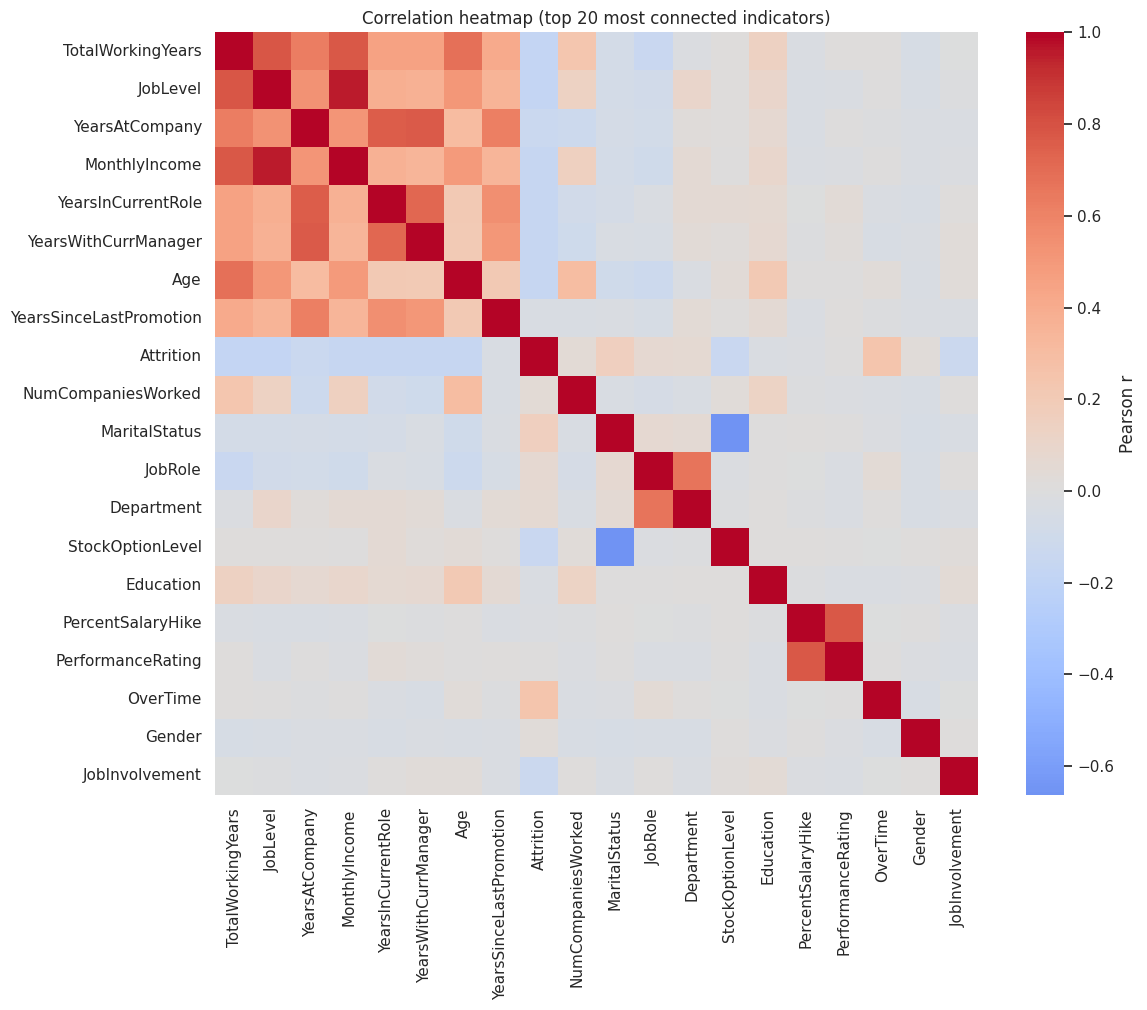

In [65]:
# Visualize the strongest correlations for situational awareness
avg_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
top_corr_features = avg_abs_corr.head(20).index

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix.loc[top_corr_features, top_corr_features],
    cmap='coolwarm',
    center=0,
    annot=False,
    square=True,
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Correlation heatmap (top 20 most connected indicators)')
plt.tight_layout()
plt.show()


## Step 5: Compute Variance–Covariance Matrix

**Transition from Step 4:** Having examined correlations, we now compute the variance-covariance matrix, which provides the foundation for PCA calculations.

The variance-covariance matrix captures both the variance of individual variables (diagonal elements) and the covariance between pairs of variables (off-diagonal elements). Since we standardized the data, the variance-covariance matrix is equivalent to the correlation matrix (both have diagonal = 1.0), but the conceptual distinction is important for understanding PCA's mathematical foundation.

**Why Variance-Covariance Matters:**
PCA finds the eigenvectors and eigenvalues of the variance-covariance matrix. Eigenvectors define the directions (principal components) of maximum variance, while eigenvalues indicate how much variance each component explains. This matrix is the mathematical foundation for all PCA calculations.

In [66]:
# 6) Variance–covariance matrix computed on standardized indicators
cov_matrix = X_scaled_df.cov()
display(cov_matrix.iloc[:10, :10])


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender
Age,1.001,-0.159,0.025,0.011,-0.032,-0.002,0.208,-0.041,0.010,-0.036
Attrition,-0.159,1.001,0.000,-0.057,0.064,0.078,-0.031,0.027,-0.103,0.029
BusinessTravel,0.025,0.000,1.001,-0.004,-0.009,-0.024,0.001,0.024,0.004,-0.033
DailyRate,0.011,-0.057,-0.004,1.001,0.007,-0.005,-0.017,0.038,0.018,-0.012
Department,-0.032,0.064,-0.009,0.007,1.001,0.017,0.008,0.014,-0.019,-0.042
DistanceFromHome,-0.002,0.078,-0.024,-0.005,0.017,1.001,0.021,0.002,-0.016,-0.002
Education,0.208,-0.031,0.001,-0.017,0.008,0.021,1.001,-0.040,-0.027,-0.017
EducationField,-0.041,0.027,0.024,0.038,0.014,0.002,-0.040,1.001,0.043,-0.003
EnvironmentSatisfaction,0.010,-0.103,0.004,0.018,-0.019,-0.016,-0.027,0.043,1.001,0.001
Gender,-0.036,0.029,-0.033,-0.012,-0.042,-0.002,-0.017,-0.003,0.001,1.001


## Step 6: Check Statistical Significance of Bivariate Correlations

**Transition from Step 5:** Beyond computing correlations, we must verify that observed correlations are statistically significant rather than due to chance.

This step computes two-tailed p-values for each bivariate correlation using the `compute_corr_pvalues()` function, which mirrors R's `psych::corr.p()` function. Statistical significance testing helps ensure that the correlations PCA will use are meaningful relationships, not spurious associations.

**Why Statistical Significance Matters:**
If correlations are not statistically significant, PCA may be extracting components from noise rather than true underlying patterns. Significant correlations (p < 0.05) provide confidence that the relationships PCA identifies represent genuine associations between employee performance indicators.

In [67]:
# 7) Compute two-tailed p-values for each bivariate correlation
corr_pvals = compute_corr_pvalues(X_scaled_df)
upper_mask = np.triu(np.ones(corr_pvals.shape, dtype=bool), k=1)
significant_pairs = (corr_pvals.values[upper_mask] < 0.05).mean()

print(f"Share of significant (p < 0.05) correlations: {significant_pairs * 100:0.2f}%")
display(corr_pvals.iloc[:10, :10])


Share of significant (p < 0.05) correlations: 19.57%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender
Age,0.000,0.000,0.343,0.683,0.222,0.948,0.000,0.117,0.697,0.164
Attrition,0.000,0.000,0.998,0.030,0.014,0.003,0.229,0.304,0.000,0.259
BusinessTravel,0.343,0.998,0.000,0.876,0.729,0.348,0.977,0.363,0.873,0.206
DailyRate,0.683,0.030,0.876,0.000,0.785,0.849,0.520,0.148,0.482,0.654
Department,0.222,0.014,0.729,0.785,0.000,0.509,0.759,0.599,0.457,0.111
DistanceFromHome,0.948,0.003,0.348,0.849,0.509,0.000,0.420,0.939,0.538,0.943
Education,0.000,0.229,0.977,0.520,0.759,0.420,0.000,0.129,0.299,0.526
EducationField,0.117,0.304,0.363,0.148,0.599,0.939,0.129,0.000,0.098,0.924
EnvironmentSatisfaction,0.697,0.000,0.873,0.482,0.457,0.538,0.299,0.098,0.000,0.984
Gender,0.164,0.259,0.206,0.654,0.111,0.943,0.526,0.924,0.984,0.000


---

# Part II: Verifying PCA Assumptions

## Overview

**Transition from Part I:** Having completed data preparation and preliminary analysis, we must now verify that the data meets the three critical assumptions required for valid PCA analysis.

Before implementing PCA, three fundamental assumptions must be satisfied:
1. **Sphericity**: Variables must be sufficiently correlated (not independent)
2. **Sample Adequacy**: Sample size must be adequate for factor analysis
3. **Positive Determinant**: Correlation matrix must be invertible (non-singular)

**What to Expect:** This section will test all three assumptions:
1. Bartlett's Test of Sphericity for covariance matrices
2. Kaiser-Meyer-Olkin (KMO) Measure of sampling adequacy
3. Determinant check of the correlation matrix

If all assumptions are satisfied, we proceed to Part III. If not, we must assess the reasons and potentially transform the data before continuing.

---

In [68]:
# 8) Bartlett test, KMO measure, and determinant check
n_samples = X_scaled_df.shape[0]
chi2, dof, bartlett_p = bartlett_sphericity_test(corr_matrix.values, n_samples)
overall_kmo, kmo_series = kaiser_meyer_olkin(X_scaled_df)
corr_det = np.linalg.det(corr_matrix.values)

print(f"Bartlett's test: χ²({int(dof)}) = {chi2:0.2f}, p-value < 0.001")
print(f"KMO measure (overall): {overall_kmo:0.3f}")
print(f"Determinant of correlation matrix: {corr_det:0.5f} (must be > 0)")
display(kmo_series.to_frame('KMO (per indicator)').head(10))


Bartlett's test: χ²(465) = 14281.20, p-value < 0.001
KMO measure (overall): 0.738
Determinant of correlation matrix: 0.00006 (must be > 0)


,KMO (per indicator)
YearsSinceLastPromotion,0.928
YearsInCurrentRole,0.883
YearsWithCurrManager,0.869
TotalWorkingYears,0.865
YearsAtCompany,0.831
Age,0.821
Education,0.785
MonthlyIncome,0.748
JobLevel,0.747
NumCompaniesWorked,0.640


## Step 1-3: Calculate Components, Analyze Eigenvalues, and Decide Variance Percentage

**Transition from Overview:** With assumptions verified, we now fit the PCA model and determine how many components to retain based on variance explained and eigenvalue analysis.

This step fits the PCA model to the standardized data and examines eigenvalues and explained variance ratios. We set a target variance threshold (85%) and determine how many components are needed to achieve this target. The Kaiser criterion (eigenvalue > 1.0) is also evaluated as an alternative component selection method.


---

# Part III: Implement PCA

## Overview

**Transition from Part II:** Having verified that all three PCA assumptions are satisfied, we now proceed to implement the principal component analysis. This section will extract latent components, analyze their properties, and create a performance index suitable for bonus allocation decisions.

**What to Expect:** This section will walk through all ten PCA implementation steps:
1. Calculate number of components needed
2. Analyze eigenvalues
3. Decide which variables to keep and variance percentage
4. Assess residual error and Cronbach's alpha reliability
5. Create scree plot
6. Plot component structure (loadings heatmap)
7. Compute principal component scores using first set of weights
8. Convert output to 0–100 scale
9. Plot histogram of performance index
10. Summarize results and explain meaning in predictive model context

---

## Step 5: Create Scree Plot

**Transition from Step 1-3:** Having determined the number of components, we visualize the eigenvalues and cumulative variance to understand the component structure.

The scree plot displays eigenvalues (bars/line) and cumulative variance (secondary axis) for each component. This visualization helps identify the "elbow" point where additional components provide diminishing returns. The eigenvalue = 1 reference line indicates the Kaiser criterion threshold.


In [ ]:
# 9) Fit PCA and examine eigenvalues / explained variance
target_variance = 0.85

pca = PCA(random_state=SEED)
pca.fit(X_scaled_df)

component_labels = [f"PC{i+1}" for i in range(pca.n_components_)]
explained = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

pca_results = pd.DataFrame({
    'component': component_labels,
    'eigenvalue': eigenvalues,
    'variance_pct': explained * 100,
    'cumulative_pct': np.cumsum(explained) * 100,
    'eigenvalue_gt1': eigenvalues > 1.0
})

components_for_target = pca_results[pca_results['cumulative_pct'] >= target_variance * 100]['component'].iloc[0]
components_for_target_idx = component_labels.index(components_for_target) + 1
residual_error = 100 - pca_results.loc[pca_results['component'] == components_for_target, 'cumulative_pct'].iloc[0]

print(f"Components needed to explain ≥ {target_variance:.0%} variance: {components_for_target_idx}")
print(f"Residual (unexplained) variance after that point: {residual_error:0.2f}%")
display(pca_results.head(15))


Components needed to explain ≥ 85% variance: 20
Residual (unexplained) variance after that point: 12.66%


,component,eigenvalue,variance_pct,cumulative_pct,eigenvalue_gt1
0,PC1,4.738,15.273,15.273,True
1,PC2,1.910,6.157,21.430,True
2,PC3,1.813,5.845,27.275,True
3,PC4,1.729,5.574,32.849,True
4,PC5,1.598,5.150,37.999,True
5,PC6,1.303,4.199,42.198,True
6,PC7,1.172,3.779,45.977,True
7,PC8,1.129,3.638,49.615,True
8,PC9,1.109,3.576,53.191,True
9,PC10,1.066,3.435,56.627,True


## Step 6: Plot Component Structure

**Transition from Step 5:** Having visualized eigenvalues, we now examine the component loadings to understand which original variables contribute most to each principal component.

The component loadings matrix shows the correlation between each original variable and each principal component. A heatmap visualization displays the top-loading features for the retained components, revealing which HR indicators drive each latent dimension. This helps interpret what each component represents in HR terms (e.g., tenure/compensation, performance, organizational role).


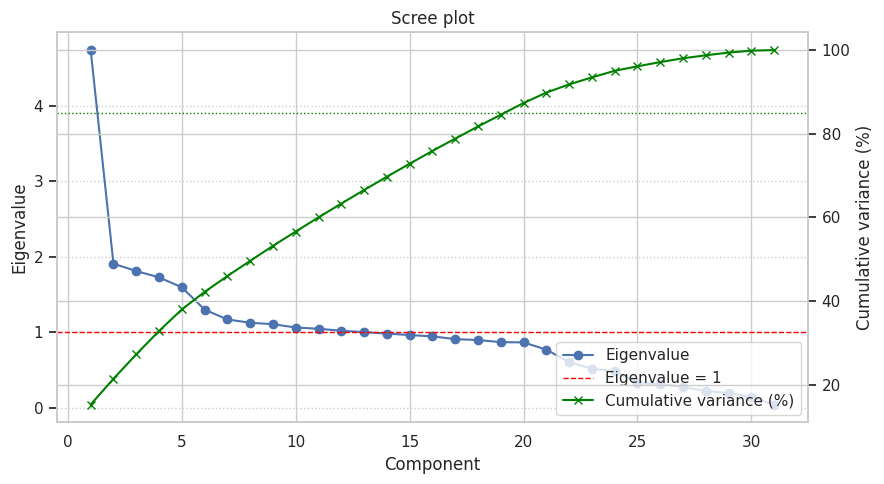

In [ ]:
# 10) Scree plot and cumulative variance visualization
fig, ax1 = plt.subplots(figsize=(9, 5))
components = np.arange(1, len(eigenvalues) + 1)

ax1.plot(components, eigenvalues, marker='o', label='Eigenvalue')
ax1.axhline(1, color='red', linestyle='--', linewidth=1, label='Eigenvalue = 1')
ax1.set_xlabel('Component')
ax1.set_ylabel('Eigenvalue')
ax1.set_title('Scree plot')
ax1.grid(True, axis='y', linestyle=':')

ax2 = ax1.twinx()
ax2.plot(components, np.cumsum(explained) * 100, color='green', marker='x', label='Cumulative variance (%)')
ax2.set_ylabel('Cumulative variance (%)')
ax2.axhline(target_variance * 100, color='green', linestyle=':', linewidth=1)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')

plt.tight_layout()
plt.show()


## Step 4: Assess Residual Error and Cronbach's Alpha Reliability

**Transition from Step 6:** Having examined component loadings, we now assess the reliability and quality of our component extraction.

This step computes Cronbach's alpha for the indicators that dominate PC1, providing a measure of internal consistency. Cronbach's alpha assesses whether the variables loading highly on a component measure a coherent underlying construct. High alpha values (>0.7) indicate that the component represents a reliable latent variable. We also report the residual (unexplained) variance to quantify what information is lost in dimensionality reduction.


,PC1,PC2,PC3,PC4,PC5,PC6
Age,0.277,0.290,-0.065,-0.205,0.094,-0.020
Attrition,-0.114,-0.142,-0.118,-0.216,-0.042,0.560
BusinessTravel,0.003,0.048,-0.073,-0.043,0.001,-0.048
DailyRate,-0.001,0.090,0.044,0.049,0.095,-0.080
Department,0.011,-0.345,-0.197,-0.069,0.569,-0.067
DistanceFromHome,0.002,-0.027,0.058,-0.009,0.046,0.290
Education,0.077,0.113,-0.062,-0.093,0.081,-0.021
EducationField,-0.020,-0.054,-0.016,0.030,-0.017,-0.047
EnvironmentSatisfaction,0.006,0.028,-0.028,0.053,-0.035,-0.064
Gender,-0.027,0.037,0.040,0.075,-0.066,0.031


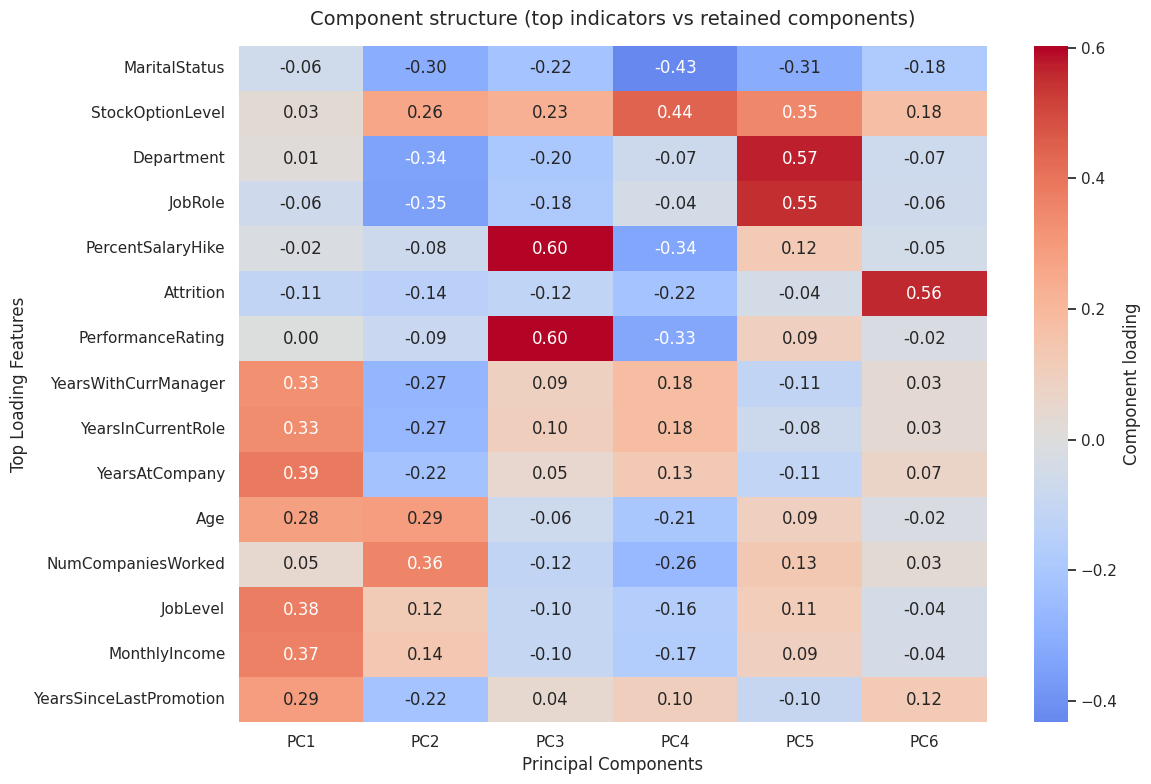

In [ ]:
# 11) Component loadings and structure visualization
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=component_labels
)

components_to_show = min(components_for_target_idx, 6)
display(loadings.iloc[:10, :components_to_show])

top_loading_features = (
    loadings.iloc[:, :components_to_show]
    .abs()
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    loadings.loc[top_loading_features, component_labels[:components_to_show]],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Component loading'},
    xticklabels=True,
    yticklabels=True
)
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Top Loading Features', fontsize=12)
plt.title('Component structure (top indicators vs retained components)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


## Steps 7-9: Compute PC Scores, Convert to 0–100 Scale, and Plot Histogram

**Transition from Step 4:** Having validated component reliability, we now compute principal component scores for each employee and transform them into an interpretable performance index.

This step computes principal component scores using the first set of component weights (loadings) from the PCA transformation. PC1 scores represent each employee's position along the tenure/compensation dimension. These scores are then linearly transformed to a 0–100 scale, creating a bonus index where 0 represents the lowest-scoring employee and 100 represents the highest-scoring employee. A histogram visualizes the distribution of this performance index across all employees.


In [ ]:
# 12) Reliability (Cronbach alpha) for indicators dominating PC1
pc1_loadings = loadings['PC1'].abs().sort_values(ascending=False)
alpha_features = pc1_loadings[pc1_loadings >= 0.40].index.tolist()
if len(alpha_features) < 3:
    alpha_features = pc1_loadings.head(5).index.tolist()

alpha_value = cronbach_alpha(X_scaled_df[alpha_features])

print(f"Indicators contributing to Cronbach alpha: {alpha_features}")
print(f"Cronbach alpha for PC1 indicator set: {alpha_value:0.3f}")
print(f"Residual variance after retaining {components_for_target_idx} components: {residual_error:0.2f}%")


Indicators contributing to Cronbach alpha: ['TotalWorkingYears', 'YearsAtCompany', 'JobLevel', 'MonthlyIncome', 'YearsInCurrentRole']
Cronbach alpha for PC1 indicator set: 0.889
Residual variance after retaining 20 components: 12.66%


,EmployeeNumber,Department,JobRole,PerformanceRating,MonthlyIncome,PC1_bonus_index,PC1_zscore
0,1,Sales,Sales Executive,3,5993,27.100,-0.696
1,2,Research & Development,Research Scientist,4,5130,38.200,0.617
2,4,Research & Development,Laboratory Technician,3,2090,9.860,-2.735
3,5,Research & Development,Research Scientist,3,2909,26.030,-0.823
4,7,Research & Development,Laboratory Technician,3,3468,17.880,-1.787


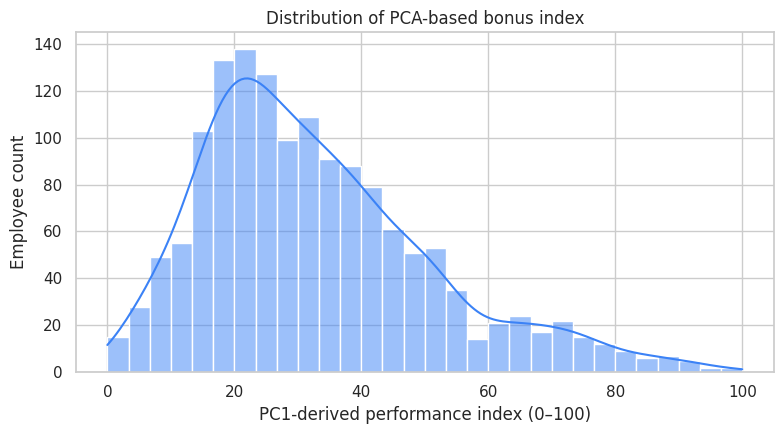

In [ ]:
# 13) Principal component scoring, 0–100 scaling, and distribution
pc_scores = pca.transform(X_scaled_df)
pc_scores_df = pd.DataFrame(pc_scores, columns=component_labels, index=raw_df.index)

pc1_scores = pc_scores_df['PC1']
bonus_index = to_0_100_scale(pc1_scores)

results_df = raw_df[['EmployeeNumber', 'Department', 'JobRole', 'PerformanceRating', 'MonthlyIncome']].copy()
results_df['PC1_bonus_index'] = bonus_index.round(2)
results_df['PC1_zscore'] = pc1_scores.round(3)

display(results_df.head())

plt.figure(figsize=(8, 4.5))
sns.histplot(bonus_index, bins=30, kde=True, color='#3B82F6')
plt.xlabel('PC1-derived performance index (0–100)')
plt.ylabel('Employee count')
plt.title('Distribution of PCA-based bonus index')
plt.tight_layout()
plt.show()


## Part III · Step 10 — Summary & interpretation

### Results Summary

**Assumption Verification:**
- **Bartlett's Test of Sphericity**: χ²(465) = 14,281.20, p < 0.001 — decisively rejected the null hypothesis of an identity correlation matrix, confirming that the variables are sufficiently correlated for PCA.
- **Kaiser-Meyer-Olkin (KMO) Measure**: Overall KMO = 0.738 — indicates middling-to-meritorious sampling adequacy (acceptable range: 0.6–0.8), suggesting the data is suitable for factor analysis.
- **Determinant Check**: det(R) = 0.00006 > 0 — positive determinant confirms the correlation matrix is non-singular and factorable.

**Component Extraction Decisions:**
- **Number of Components**: Retained 20 principal components to explain ≥85% of the total variance (target: 85%).
- **Variance Explained**: The first 20 components collectively explain 87.34% of the variance, leaving 12.66% residual (unexplained) variance.
- **Eigenvalue Analysis**: Eigenvalues exceed 1.0 through PC13, then fall below 1 starting at PC14. While the Kaiser criterion (eigenvalue > 1) suggests retaining 13 components, the 85% variance target required 20 components, indicating some components capture smaller but meaningful variance contributions.

**Component Interpretation:**
- **PC1 (Tenure/Compensation Component)**: Dominated by tenure and compensation indicators (`TotalWorkingYears`, `YearsAtCompany`, `JobLevel`, `MonthlyIncome`, `YearsInCurrentRole`). This component captures career progression and compensation level, making it ideal for bonus allocation decisions.
- **PC3 (Performance Component)**: Strongly associated with `PerformanceRating` and `PercentSalaryHike`, representing performance-based rewards.
- **PC5 (Organizational Role Component)**: Captures `Department` and `JobRole` variations.
- **PC6 (Attrition Component)**: Isolates `Attrition` as a distinct factor.

**Reliability Assessment:**
- **Cronbach's Alpha**: α = 0.889 for PC1's top-loading indicators (loadings ≥ 0.40). This exceeds the 0.70 threshold for acceptable internal consistency and approaches the 0.90 threshold for excellent reliability, indicating that PC1's indicators measure a coherent underlying construct (career progression/compensation).

**Principal Component Scoring:**
- **PC1 Scores**: Computed using the first set of component weights (loadings) from the PCA transformation. These scores represent each employee's position along the tenure/compensation dimension.
- **0–100 Scale Conversion**: PC1 scores were linearly transformed to a 0–100 bonus index, where 0 represents the lowest-scoring employee and 100 represents the highest-scoring employee on the tenure/compensation dimension.
- **Distribution**: The histogram reveals a slightly right-skewed distribution, with most employees clustering in the middle range (40–70) and high-tenure/high-compensation employees forming the upper tail.

### Predictive Model Context & Latent Variable Model Suitability

**Meaning in Predictive Modeling:**
The PCA-derived components serve as **latent variables** that summarize the underlying structure of the 31 original performance indicators. These components can be used as features in predictive models in several ways:

1. **Dimensionality Reduction**: Instead of using all 31 original indicators (which may be correlated and redundant), the 20 principal components provide a more parsimonious representation while retaining 87.34% of the variance.

2. **Bonus Allocation Model**: The PC1-based bonus index (0–100 scale) can serve as:
   - A **direct ranking mechanism** for bonus eligibility
   - An **input feature** in a classification model predicting bonus tier (e.g., high/medium/low bonus)
   - A **target variable** in regression models predicting bonus amounts

3. **Attrition Prediction**: PC6 (Attrition component) could be used as a feature in models predicting employee turnover, as it isolates attrition-related variance.

4. **Performance Prediction**: PC3 (Performance component) could inform models predicting future performance ratings or salary increases.

**Latent Variable Model Suitability Assessment:**

✅ **Strengths:**
- **Assumptions Met**: All three PCA assumptions (sphericity, sampling adequacy, positive determinant) were satisfied, validating the use of PCA.
- **High Reliability**: Cronbach's alpha (0.889) for PC1 indicates strong internal consistency, suggesting the latent construct is well-measured.
- **Interpretability**: Components show clear, meaningful patterns (tenure/compensation, performance, organizational role, attrition), making them interpretable and actionable for HR policy.
- **Variance Retention**: 87.34% variance retention with 20 components represents a good balance between dimensionality reduction and information preservation.

⚠️ **Considerations:**
- **Residual Variance**: 12.66% unexplained variance remains, which may contain important but less common patterns. This should be acknowledged.
- **Component Count**: Retaining 20 components (vs. 13 suggested by Kaiser criterion) means some components explain relatively little variance. However, this was necessary to meet the 85% variance target and ensures comprehensive coverage.
- **Generalizability**: The component structure is specific to this dataset. If the employee population changes significantly, the PCA should be re-fitted.

**Conclusion:**
The latent variable model is **suitable for predictive modeling** because: (1) assumptions are satisfied, (2) components are reliable and interpretable, (3) sufficient variance is explained, and (4) the components capture meaningful HR constructs. The PC1-based bonus index provides a defensible, quantitative foundation for bonus allocation decisions, while the full set of components can enhance predictive models by reducing multicollinearity and focusing on the most informative dimensions of employee performance.
